# Simple Example of Multi-agent by using LangGraph

In [146]:
from langgraph.graph import START, END#, MessagesState, StateGraph
from langgraph.graph.message import MessagesState, StateGraph
from typing import Literal
from langgraph.types import Command
from IPython.display import Image, display

In [147]:
# Define Custom State for Supervisor
class SupervisorState(MessagesState):
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""

In [148]:
# Controller: Supervisor Router

def supervisor_agent(state: SupervisorState) -> Command[Literal["Researcher", "Analyzer", "Reporter", "__end__"]]:
    
    # print("Supervisor Agent\n",state)
    next_node= state.get('next_agent')
    # state["next_agent"]= next_agent
    # print(next_node)

    if next_node == "end":
        print(f"<- Well Done!!!, All Task has been Completed->")
        next_node= END
    else:
        print(f"<- Supervisor is assigning task to {state.get('next_agent')}->")
    # return Command(goto=next_agent, update={"next_agent": next_agent})
    return Command(goto=next_node, update={'next_agent': next_node})

In [196]:
# Agent 1: Researcher

def research_agent(state: SupervisorState) -> Command[Literal["Supervisor"]]:
    print("<- Agent 1: Researcher is working ->")
    # state["research_data"]= "LangGraph is a library for building agent workflows."
    research_data= "LangGraph is a library for building agent workflows."
    state["messages"].append({"role": "assistant", "content": "Research has been completed."})
    state["next_agent"]= "Analyzer"
    # next_node= "Analyzer"
    # print("research_agent\n",state)
    return Command(goto="Supervisor", update={'next_agent': state["next_agent"], 'research_data': research_data})

In [150]:
# Agent 2: Analyzer

def analyzer_agent(state: SupervisorState) -> Command[Literal["Supervisor"]]:
    print("<- Agent 2: Analyzer is working ->")
    data= state.get("research_data", "")
    # state["analysis"]= f"Summary: {data[:30]}..."
    analysis= f"Summary: {data[:30]}..."
    state["messages"].append({"role": "assistant", "content": "Analysis has been done."})
    # state["next_agent"]= "Reporter"
    next_node= "Reporter"
    # print("analyzer_agent\n",state)
    return Command(goto="Supervisor", update={'next_agent': next_node, 'analysis': analysis})

In [151]:
# Agent 3: Report Writer

def report_agent(state: SupervisorState) -> Command[Literal["Supervisor"]]:
    print("<- Agent 3: Report Writer is working ->")
    analysis = state.get("analysis", "")
    # state["final_report"] = f"Final Report: Based on - {analysis}"
    final_report = f"Final Report: Based on - {analysis}"
    state["messages"].append({"role": "assistant", "content": "Report has been generated."})
    # state["next_agent"] = "end"
    next_node= "end"
    # print("report_agent\n",state)
    return Command(goto="Supervisor", update={'next_agent': next_node, 'final_report': final_report})

In [197]:
# Build graph
builder = StateGraph(SupervisorState)

# Add agent nodes
builder.add_node("Researcher", research_agent)
builder.add_node("Analyzer", analyzer_agent)
builder.add_node("Reporter", report_agent)
builder.add_node("Supervisor", supervisor_agent)

# Set Start Point Node
builder.add_edge(START, "Supervisor")

In [198]:
# Compile
graph = builder.compile()

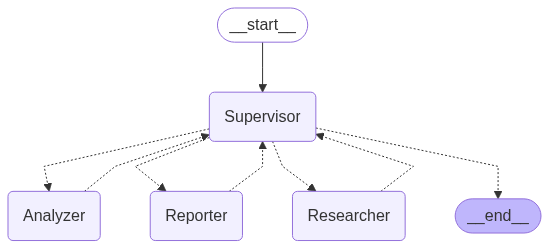

In [154]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
final_state= graph.invoke({'messages': [{'role': 'user', 'content': 'Start the task'}],
 'next_agent': 'Researcher'})

<- Supervisor is assigning task to Researcher->
<- Agent 1: Researcher is working ->
<- Supervisor is assigning task to Analyzer->
<- Agent 2: Analyzer is working ->
<- Supervisor is assigning task to Reporter->
<- Agent 3: Report Writer is working ->
<- Well Done!!!, All Task has been Completed->


In [156]:
final_state

{'messages': [HumanMessage(content='Start the task', additional_kwargs={}, response_metadata={}, id='49d6ef94-c015-4fa8-aa1e-822365e04035'),
  {'role': 'assistant', 'content': 'Research has been completed.'},
  {'role': 'assistant', 'content': 'Analysis has been done.'},
  {'role': 'assistant', 'content': 'Report has been generated.'}],
 'next_agent': '__end__',
 'research_data': 'LangGraph is a library for building agent workflows.',
 'analysis': 'Summary: LangGraph is a library for bui...',
 'final_report': 'Final Report: Based on - Summary: LangGraph is a library for bui...'}

In [157]:
initial_state={'messages': [{'role': 'user', 'content': 'Start the task'}],
                'next_agent': 'Researcher'
        }

In [158]:
initial_state

{'messages': [{'role': 'user', 'content': 'Start the task'}],
 'next_agent': 'Researcher'}

In [ ]:
final_state= graph.invoke(initial_state)

<- Supervisor is assigning task to Researcher->
<- Agent 1: Researcher is working ->
<- Supervisor is assigning task to Analyzer->
<- Agent 2: Analyzer is working ->
<- Supervisor is assigning task to Reporter->
<- Agent 3: Report Writer is working ->
<- Well Done!!!, All Task has been Completed->


In [160]:
final_state

{'messages': [HumanMessage(content='Start the task', additional_kwargs={}, response_metadata={}, id='e42a7e4d-3354-4e68-8f55-74f6a5a89fee'),
  {'role': 'assistant', 'content': 'Research has been completed.'},
  {'role': 'assistant', 'content': 'Analysis has been done.'},
  {'role': 'assistant', 'content': 'Report has been generated.'}],
 'next_agent': '__end__',
 'research_data': 'LangGraph is a library for building agent workflows.',
 'analysis': 'Summary: LangGraph is a library for bui...',
 'final_report': 'Final Report: Based on - Summary: LangGraph is a library for bui...'}

In [180]:
initial_state= SupervisorState(messages= [{'role': 'user', 'content': 'Start the task'}],
                              next_agent='Researcher'
                            )

In [181]:
print(type(initial_state))

<class 'dict'>


In [182]:
initial_state

{'messages': [{'role': 'user', 'content': 'Start the task'}],
 'next_agent': 'Researcher'}

In [199]:
final_state= graph.invoke(initial_state)

<- Supervisor is assigning task to Researcher->
<- Agent 1: Researcher is working ->
<- Supervisor is assigning task to Analyzer->
<- Agent 2: Analyzer is working ->
<- Supervisor is assigning task to Reporter->
<- Agent 3: Report Writer is working ->
<- Well Done!!!, All Task has been Completed->


In [190]:
final_state

{'messages': [HumanMessage(content='Start the task', additional_kwargs={}, response_metadata={}, id='e554eda7-de13-4501-b4b8-3e182c082ba0'),
  {'role': 'assistant', 'content': 'Research has been completed.'},
  {'role': 'assistant', 'content': 'Analysis has been done.'},
  {'role': 'assistant', 'content': 'Report has been generated.'}],
 'next_agent': '__end__',
 'research_data': 'LangGraph is a library for building agent workflows.',
 'analysis': 'Summary: LangGraph is a library for bui...',
 'final_report': 'Final Report: Based on - Summary: LangGraph is a library for bui...'}

In [179]:
final_state["messages"]

[HumanMessage(content='Start the task', additional_kwargs={}, response_metadata={}, id='7a01bcf5-33c9-4c2c-b0f2-e70c7512ee84'),
 {'role': 'assistant', 'content': 'Research has been completed.'},
 {'role': 'assistant', 'content': 'Analysis has been done.'},
 {'role': 'assistant', 'content': 'Report has been generated.'}]